In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l
from torch import nn


In [2]:
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1: return torch.zeros_like(X)
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

In [3]:
X = torch.arange(16, dtype = torch.float32).reshape((2, 8))
print('dropout_p = 0:', dropout_layer(X, 0))
print('dropout_p = 0.5:', dropout_layer(X, 0.5))
print('dropout_p = 1:', dropout_layer(X, 1))

dropout_p = 0: tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
dropout_p = 0.5: tensor([[ 0.,  0.,  4.,  0.,  0.,  0., 12., 14.],
        [16.,  0.,  0., 22.,  0., 26.,  0.,  0.]])
dropout_p = 1: tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [4]:
class DropoutMLPScratch(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2, dropout_1, dropout_2, lr):
        super().__init__()
        self.save_hyperparameters()
        self.lin1 = nn.LazyLinear(num_hiddens_1)
        self.lin2 = nn.LazyLinear(num_hiddens_2)
        self.lin3 = nn.LazyLinear(num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((X.shape[0], -1))))
        if self.training:
            H1 = dropout_layer(H1, self.dropout_1)
        H2 = self.relu(self.lin2(H1))
        if self.training:
            H2 = dropout_layer(H2, self.dropout_2)
        return self.lin3(H2)


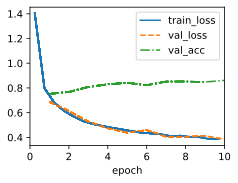

In [5]:
hparams = {
    "num_outputs": 10,
    "num_hiddens_1": 256,
    "num_hiddens_2": 256,
    "dropout_1": 0.25,
    "dropout_2": 0.5,
    "lr": 0.1
}

model = DropoutMLPScratch(**hparams)
trainer = d2l.Trainer(max_epochs=10)
data = d2l.FashionMNIST(batch_size=256)
trainer.fit(model, data)

In [14]:
class DropoutMLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2, dropout_1, dropout_2, lr, weight_decay=0.0):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hiddens_1),
            nn.ReLU(),
            nn.Dropout(dropout_1),
            nn.LazyLinear(num_hiddens_2),
            nn.ReLU(),
            nn.Dropout(dropout_2),
            nn.LazyLinear(num_outputs)
        )

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)

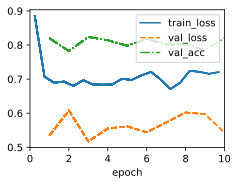

In [17]:
model = DropoutMLP(10, 256, 256, 0.5, 0.5, 0.01, 0.0001)
trainer.fit(model, data)

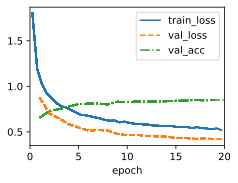

In [8]:
model = DropoutMLP(10, 256, 256, 0.8, 0.8, 0.1)
trainer = d2l.Trainer(max_epochs=20)
trainer.fit(model, data)

### dropout_1 = 0.1 & dropout_2 = 0.1

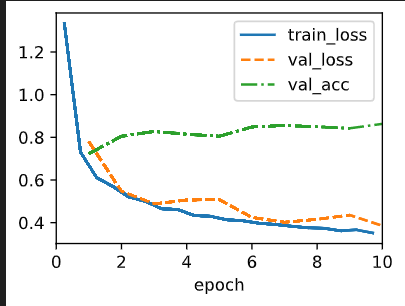

### dropout_1 = 0.5 & dropout_2 = 0.5
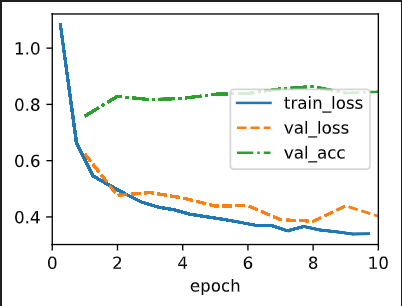

### dropout_1 = 0.8 & dropout_2 = 0.8. Slight decrease in validation accuracy
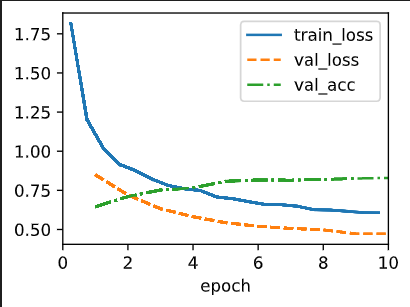

### dropout_1 = 1.0 & dropout_2 = 1.0. The network stops learning
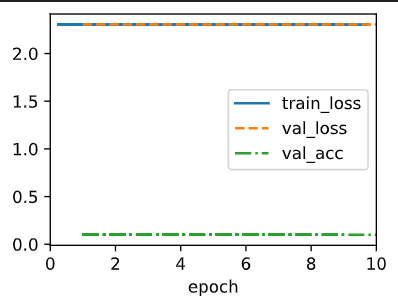

### dropout_1 = 0 & dropout_2 = 0 & num_epochs=20. Not much change.
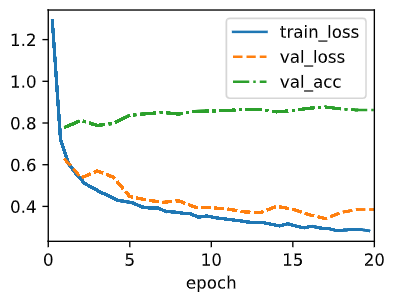

### dropout_1 = 0.5 & dropout_2 = 0.5 & num_epochs=20. Validation loss and Train loss are very close to each other which indicates low generalization gap.
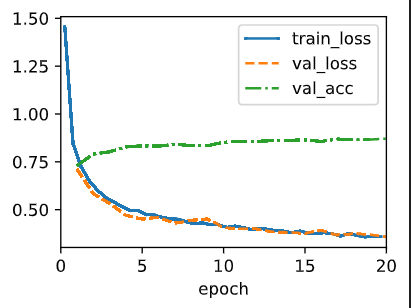

### dropout_1 = 0.8 & dropout_2 = 0.8 & num_epochs=20. Not much difference

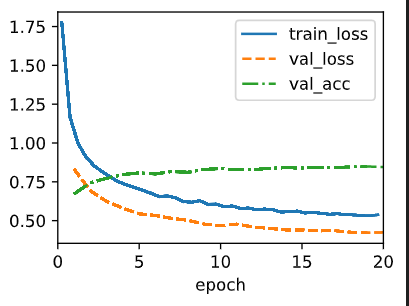

In [9]:
#Finding variance of activations across layers
class MLPActVar(d2l.Module):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2, dropout_1, dropout_2, lr=0.1):
        super().__init__()
        self.save_hyperparameters()
        self.activations_var = {
            "hidden_layer1":[],
            "hidden_layer2":[],
        }
        self.lin1 = nn.LazyLinear(num_hiddens_1)
        self.lin2 = nn.LazyLinear(num_hiddens_2)
        self.lin3 = nn.LazyLinear(num_outputs)
        self.relu = nn.ReLU()
        self.dropout_1 = nn.Dropout(dropout_1)
        self.dropout_2 = nn.Dropout(dropout_2)

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((X.shape[0], -1))))
        H1 = self.dropout_1(H1)
        if self.training:
            with torch.no_grad():
                var_H1 = torch.var(H1, dim=0).mean()
                self.activations_var["hidden_layer1"].append(var_H1.detach().numpy())

        H2 = self.relu(self.lin2(H1))
        H2 = self.dropout_2(H2)

        if self.training:
            with torch.no_grad():
                var_H2 = torch.var(H2, dim=0).mean()
                self.activations_var["hidden_layer2"].append(var_H2.detach().numpy())
        return self.lin3(H2)
    
    def loss(self, y_hat, y, averaged=True):
        l = nn.CrossEntropyLoss(reduction='mean' if averaged else 'none')
        return l(input=y_hat, target=y)
    
    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)
    
    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        return l
    
    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        print("Validation loss : ", l.detach().numpy())
        return l        
    


In [10]:
model = MLPActVar(10, 256, 256, 0.0, 0.0, 0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

Validation loss :  0.6001006
Validation loss :  0.60350806
Validation loss :  0.73685807
Validation loss :  0.7078144
Validation loss :  0.74729764
Validation loss :  0.6208015
Validation loss :  0.63528347
Validation loss :  0.67724437
Validation loss :  0.5925818
Validation loss :  0.5861302
Validation loss :  0.7348088
Validation loss :  0.8100762
Validation loss :  0.8606742
Validation loss :  0.7519028
Validation loss :  0.7270598
Validation loss :  0.74274075
Validation loss :  0.7046402
Validation loss :  0.50463146
Validation loss :  0.68567723
Validation loss :  0.72317976
Validation loss :  0.702917
Validation loss :  0.7360594
Validation loss :  0.748444
Validation loss :  0.6269441
Validation loss :  0.66670465
Validation loss :  0.6764168
Validation loss :  0.7550758
Validation loss :  0.64715356
Validation loss :  0.68182117
Validation loss :  0.65708333
Validation loss :  0.7314343
Validation loss :  0.7175179
Validation loss :  0.65241736
Validation loss :  0.6282787
Va

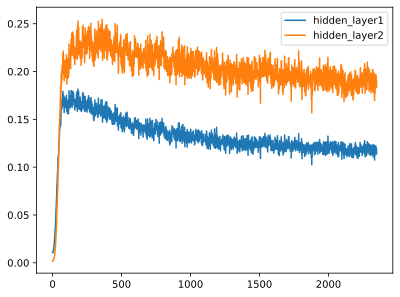

In [11]:
import matplotlib.pyplot as plt

plt.plot(model.activations_var["hidden_layer1"])
plt.plot(model.activations_var["hidden_layer2"])
plt.legend(["hidden_layer1", "hidden_layer2"])
plt.show()


In [12]:
#Calculate mean of variance

layer1_mean = sum(model.activations_var["hidden_layer1"])/len(model.activations_var["hidden_layer1"])
layer2_mean = sum(model.activations_var["hidden_layer2"])/len(model.activations_var["hidden_layer2"])


print("Mean of hidden layer 1 : ", layer1_mean)
print("Mean of hidden layer 2 : ",layer2_mean)

Mean of hidden layer 1 :  0.1321752391180935
Mean of hidden layer 2 :  0.20165771721282658


### Variance of activations across layer 1 and layer 2 with dropout = 0.8
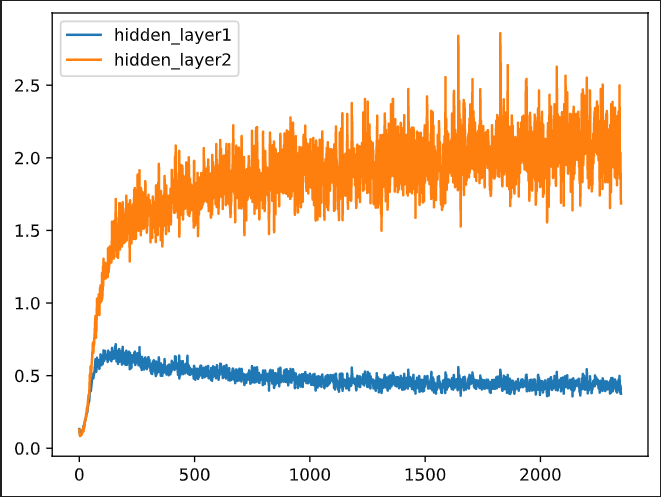
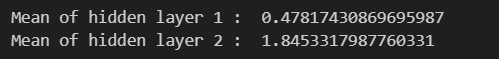

### Variance of activations across layer 1 and layer 2 with no dropout

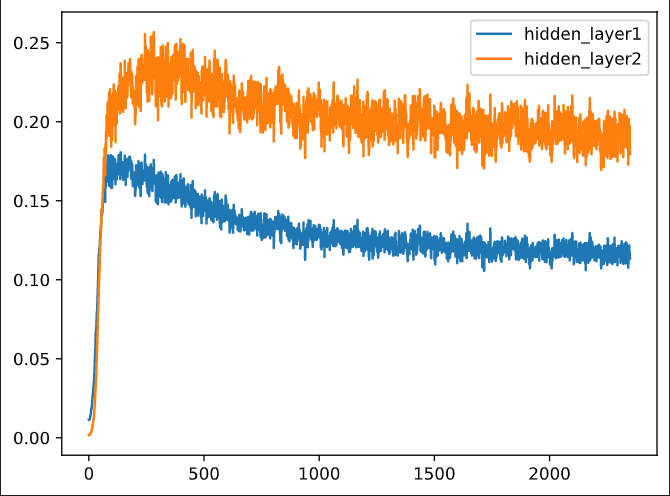
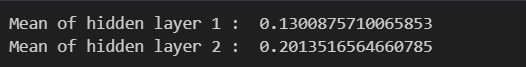


### Dropout increases the variance of activations in every layer. A model without dropout will naturally show lower activation variance.

### dropout_1 = 0.0 & dropout_2 = 0.0 & lr = 0.1 & weight_decay=0.001. Model seems to underfit.
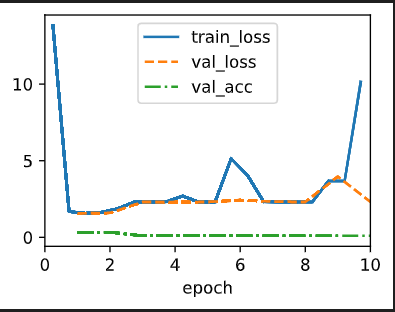

### dropout_1 = 0.0 & dropout_2 = 0.0 & lr = 0.01 & weight_decay=0.0001. Training and Validation loss decreased by almost 0.1 compared to 
### model with dropout_1 = 0.5 & dropout_2 = 0.5 & lr = 0.01 & weight_decay=0.0
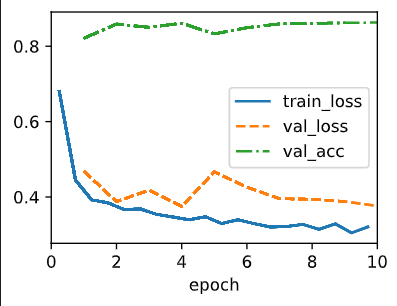

### dropout_1 = 0.5 & dropout_2 = 0.5 & lr = 0.01 & weight_decay=0.0001. 
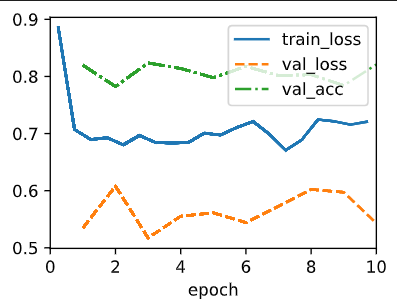

In [28]:
from torch.nn import functional as F

#A custom model where we dropout weights rather than activations
class MLPWeightDroput(d2l.Classifier):
    def __init__(self, num_hiddens_1,num_hiddens_2, num_inputs, num_outputs, lr, dropout_1, dropout_2):
        super().__init__()
        self.save_hyperparameters()
        self.W1 = nn.Parameter(torch.normal(size=(num_inputs, num_hiddens_1) ,mean=0, std=0.1))
        self.b1 = nn.Parameter(torch.zeros(num_hiddens_1))
        self.W2 = nn.Parameter(torch.normal(size=(num_hiddens_1, num_hiddens_2) ,mean=0, std=0.1))
        self.b2 = nn.Parameter(torch.zeros(num_hiddens_2))
        self.W3 = nn.Parameter(torch.normal(size=(num_hiddens_2, num_outputs) ,mean=0, std=0.1))
        self.b3 = nn.Parameter(torch.zeros(num_outputs))

    def forward(self, X):
        Z1 = torch.matmul(X.reshape(X.shape[0], -1), self.dropout_layer(self.W1, self.dropout_1)) + self.b1
        H1 = F.relu(Z1)
        Z2 = torch.matmul(H1, self.dropout_layer(self.W2, self.dropout_2)) + self.b2
        H2 = F.relu(Z2)
        Z3 = torch.matmul(H2, self.W3) + self.b3
        return Z3
    
    def dropout_layer(self, X, dropout):
        assert 0 <= dropout <= 1
        if dropout == 1: return torch.zeros_like(X)
        mask = (torch.rand(X.shape) > dropout).float()
        return mask * X / (1.0 - dropout)
        

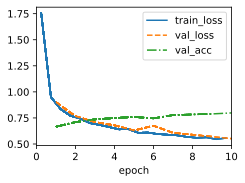

In [29]:
model = MLPWeightDroput(256, 256, 784, 10, 0.1, 0.5, 0.5)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)